First of all, imports and some global variables


In [23]:
import torch
import matplotlib.pyplot as plt
import numpy as np

import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.dataset import CocoSegDataset
from src.model import UNet

# Flag for using CUDA by default if available.
# For debugging or in case of unexpected errors change it to False
use_cuda = True


# Step 0 - Sanity check for dataset import

Checking image and mask shapes

In [24]:
dataset = CocoSegDataset(
    image_dir="../data/train/images",
    json_path="../data/train/train.json"
)

img, mask = dataset[0]
print(img.shape)   # (3, H, W)
print(mask.shape)  # (1, H, W)
print(mask.max())



torch.Size([3, 160, 160])
torch.Size([1, 160, 160])
tensor(1.)


# Step 1 - Overfitting 1 image
This step helps us to see and catch underlying technical mistakes. We overfit the model to confirm that the loss is converging to 0, and we do it for one image not to lose hours with the whole dataset

### Step 1.1 - Training our model

Reference training times: <br>
**Intel Core i7-12700H:** ~25s <br>
**NVIDIA GeForce RTX 3060 (Laptop) GPU 6GB:** ~21s

In [25]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0), "" if use_cuda else "available, but using CPU now")
print("Training is running, shouldn't take more than 1-2 minutes, even with CPU only ...")
!python ../src/train.py --train_range 1 --batch_size 1 --num_epochs 200 --use_cuda use_cuda

True
NVIDIA GeForce RTX 3060 Laptop GPU 
Training is running, shouldn't take more than 1-2 minutes, even with CPU only ...
Running training with train_range= 1 , batch_size= 1 , num_epochs= 200 .
Using device:  cuda
Epoch [1/200] | train_loss: 0.0000 | val_loss: 0.6865
Saved best model
Epoch [2/200] | train_loss: 0.0000 | val_loss: 0.6351
Saved best model
Epoch [3/200] | train_loss: 0.0000 | val_loss: 0.4656
Saved best model
Epoch [4/200] | train_loss: 0.0000 | val_loss: 0.0706
Saved best model
Epoch [5/200] | train_loss: 0.0000 | val_loss: 0.1282
Epoch [6/200] | train_loss: 0.0000 | val_loss: 0.0530
Saved best model
Epoch [7/200] | train_loss: 0.0000 | val_loss: 0.0692
Epoch [8/200] | train_loss: 0.0000 | val_loss: 0.0574
Epoch [9/200] | train_loss: 0.0000 | val_loss: 0.0477
Saved best model
Epoch [10/200] | train_loss: 0.0000 | val_loss: 0.0530
Epoch [11/200] | train_loss: 0.0000 | val_loss: 0.0548
Epoch [12/200] | train_loss: 0.0000 | val_loss: 0.0505
Epoch [13/200] | train_loss: 0.

### Step 1.2 - Visualization of the data
In this step, we will take an actual look at what we just achieved.
First, let's see the original data from the dataset

In [26]:
image_dir = PROJECT_ROOT / "data" / "train" / "images"
json_path = PROJECT_ROOT / "data" / "train" / "train.json"

dataset = CocoSegDataset(
    image_dir = str(image_dir),
    json_path = str(json_path)
)

print ("Dataset size: ", len(dataset))

Dataset size:  3177


Now visualize it the first image (index=0)

Image shape:  torch.Size([3, 160, 160])
Mask shape:  torch.Size([1, 160, 160])
Image min/max,  0.0 1.0


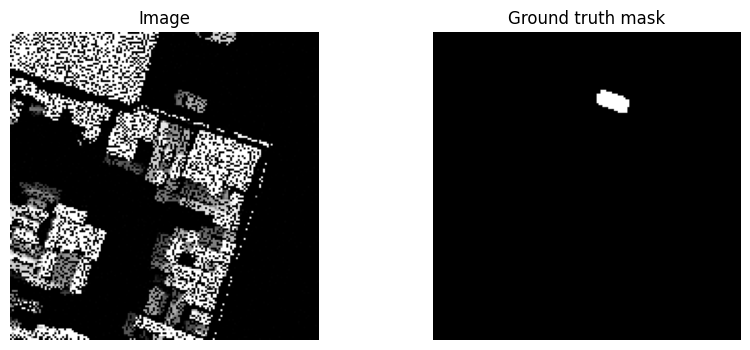

In [27]:
idx = 0

image, mask = dataset[idx]

# first, let's take a look at the image and mask attributes
print("Image shape: ", image.shape)
print("Mask shape: ", mask.shape)
print("Image min/max, ", image.min().item(), image.max().item())

# Plotting it
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(image.permute(1,2,0))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Ground truth mask")
plt.imshow(mask.squeeze(), cmap="gray")
plt.axis("off")

plt.show()

Overlaying the ground truth mask on the image

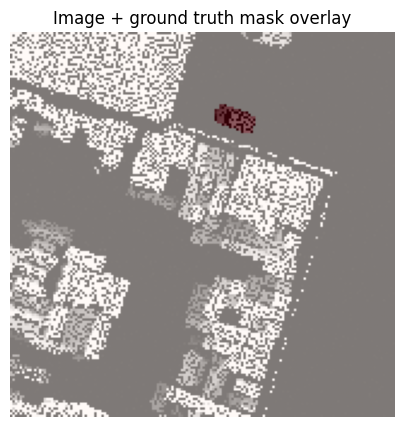

In [28]:
img_np = image.permute(1,2,0).numpy()
mask_np = mask.squeeze().numpy()

plt.figure(figsize=(5,5))
plt.title("Image + ground truth mask overlay")
plt.imshow(img_np)
plt.imshow(mask_np, alpha=0.5, cmap="Reds")
plt.axis("off")
plt.show()

### Step 1.3 - Applying our model

First, let's load the model we trained in Step 1.1

In [29]:
# try CUDA if it's possible
device = torch.device("cuda" if torch.cuda.is_available() and use_cuda else "cpu")

# loading our model to the device
model = UNet().to(device)

# loading our best model
checkpoint_path = PROJECT_ROOT / "checkpoints" / "best_model.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))

# evaluation
model.eval()

print("Loaded model from: ", checkpoint_path)

Loaded model from:  D:\_LEARN\_ComputerVision\Kaggle\Segmentation-Lidar\segment-vehicle-lidar\checkpoints\best_model.pth


C:\Users\slajcho\AppData\Local\Temp\ipykernel_30452\3063080368.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_loca

### Step 1.4 - Predicting on the same image as above

In [30]:
def predict():
    with torch.no_grad():
        input_image = image.unsqueeze(0).to(device)
        logits = model(input_image)

        # we apply sigmoid here and not baked in the model.
        # The output of the model is raw logits.
        # This is because we use BCEWithLogitsLoss loss function. As the name suggests, it works with Logits, not with probabilities
        # Please refer to the PyTorch documentation: https://docs.pytorch.org/docs/2.12/generated/torch.nn.BCEWithLogitsLoss.html
        probs = torch.sigmoid(logits)
        pred_mask = (probs > 0.5).float()
        return pred_mask, probs


### Step 1.5 - Visualizing the raw image, ground truth and prediction

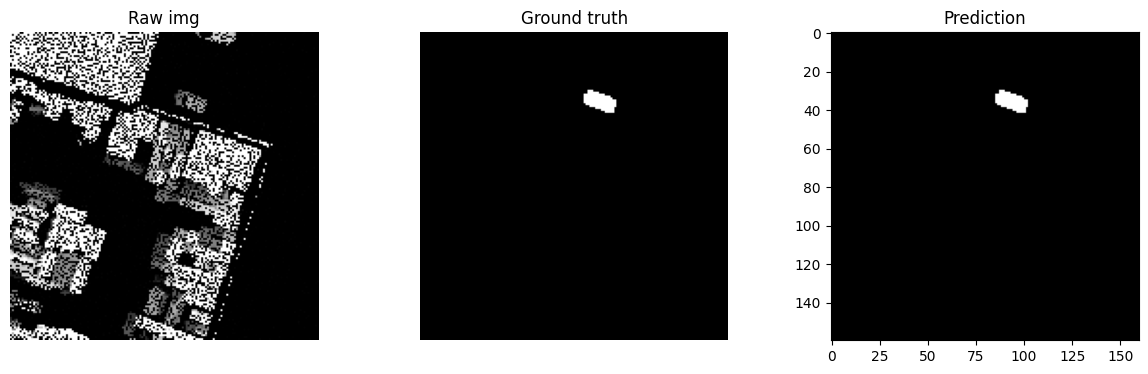

In [31]:
pred_mask, probs = predict()
pred_np = pred_mask.squeeze().cpu().numpy()

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.title("Raw img")
plt.imshow(image.permute(1,2,0))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Ground truth")
plt.imshow(mask.squeeze(), cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred_np, cmap="gray")

plt.show()

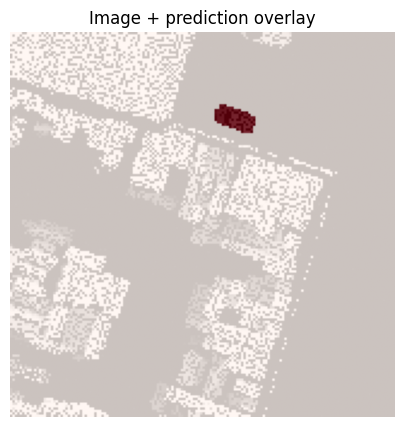

In [32]:
plt.figure(figsize=(5, 5))
plt.title("Image + prediction overlay")
plt.imshow(image.permute(1, 2, 0))
plt.imshow(pred_np, alpha=0.8, cmap="Reds")
plt.axis("off")
plt.show()

Let's check some statistics. How many pixels are positively marked, and check the probability values in our prediction. For these values you should get a value close to 1.0

In [33]:
gt_pixels = mask.sum().item()
pred_mask, probs = predict()
pred_pixels = pred_mask.sum().item()

print("GT positive pixels:", gt_pixels)
print("Pred positive pixels:", pred_pixels)

print("Probability min:", probs.min().item())
print("Probability max:", probs.max().item())
print("Probability mean:", probs.mean().item())

gt_bool = mask.squeeze().bool().to(device)
prob_map = probs[0, 0]

print("Mean prob on GT vehicle pixels:", prob_map[gt_bool].mean().item())
print("Max prob on GT vehicle pixels:", prob_map[gt_bool].max().item())

GT positive pixels: 135.0
Pred positive pixels: 135.0
Probability min: 0.0
Probability max: 0.9999992847442627
Probability mean: 0.0052828178741037846
Mean prob on GT vehicle pixels: 0.9899274706840515
Max prob on GT vehicle pixels: 0.9999992847442627


# Step 2 - Overfitting 10 images

### Step 2.1
Now we are going to train our model on 10 images. The results are going to be sometimes better, sometimes worse, but train loss should be close to 0 and val loss should be something around 0.0015. This is exactly our goal: Overfitting for a small amount of images, just to see if everything under the hood works as it's meant to.

The combination of low training loss and high validation loss is a sign of high variance and overfitting. This means we are on the right path

Reference training times: <br>
**Intel Core i7-12700H:** ~1m10s <br>
**NVIDIA GeForce RTX 3060 (Laptop) GPU 6GB:** ~1m 2s

In [34]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0), "" if use_cuda else "available, but using CPU now")
print("Training is running, shouldn't take more than a few minutes, even with CPU only ...")
%run -i ../src/train.py --train_range 10 --batch_size 2 --num_epochs 100 --use_cuda use_cuda

True
NVIDIA GeForce RTX 3060 Laptop GPU 
Training is running, shouldn't take more than a few minutes, even with CPU only ...
Running training with train_range= 10 , batch_size= 2 , num_epochs= 100 .
Using device:  cuda
Epoch [1/100] | train_loss: 0.0000 | val_loss: 0.0968
Saved best model
Epoch [2/100] | train_loss: 0.0000 | val_loss: 0.0926
Saved best model
Epoch [3/100] | train_loss: 0.0000 | val_loss: 0.0613
Saved best model
Epoch [4/100] | train_loss: 0.0000 | val_loss: 0.0506
Saved best model
Epoch [5/100] | train_loss: 0.0000 | val_loss: 0.0479
Saved best model
Epoch [6/100] | train_loss: 0.0000 | val_loss: 0.0459
Saved best model
Epoch [7/100] | train_loss: 0.0000 | val_loss: 0.0438
Saved best model
Epoch [8/100] | train_loss: 0.0000 | val_loss: 0.0421
Saved best model
Epoch [9/100] | train_loss: 0.0000 | val_loss: 0.0404
Saved best model
Epoch [10/100] | train_loss: 0.0000 | val_loss: 0.0390
Saved best model
Epoch [11/100] | train_loss: 0.0000 | val_loss: 0.0374
Saved best mode

### Step 2.2 - Visualization
We are going to use our model trained in the cell above to do inference on some images.

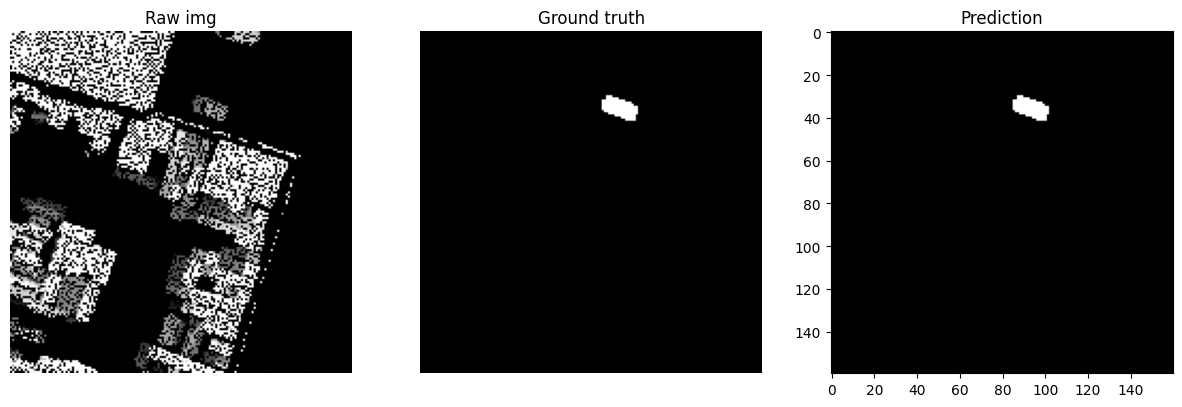

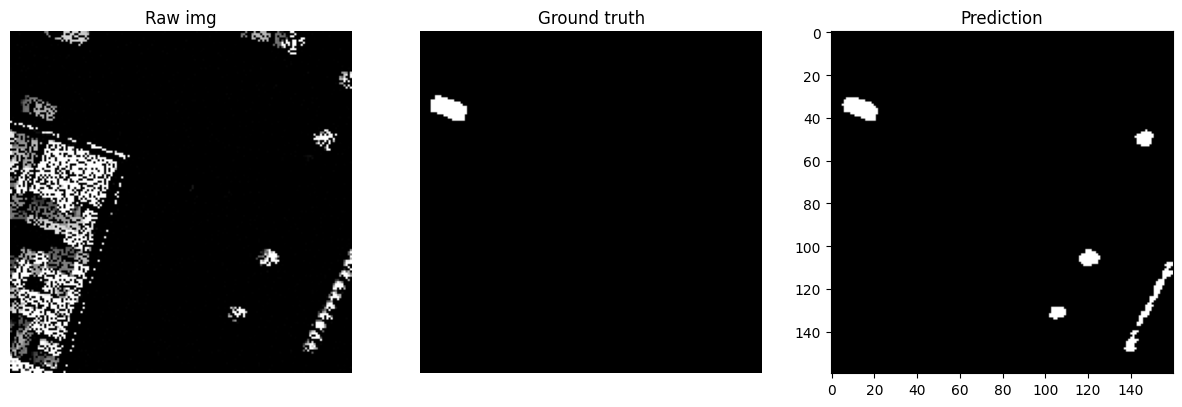

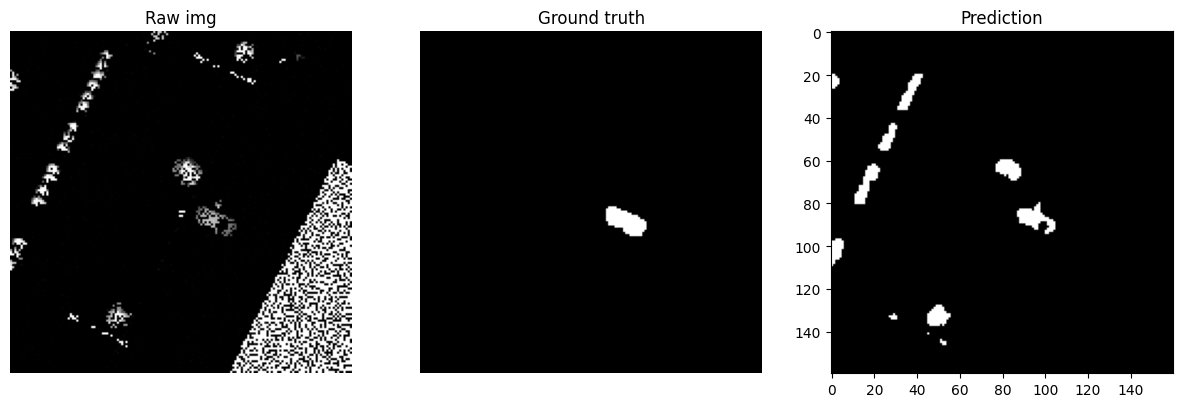

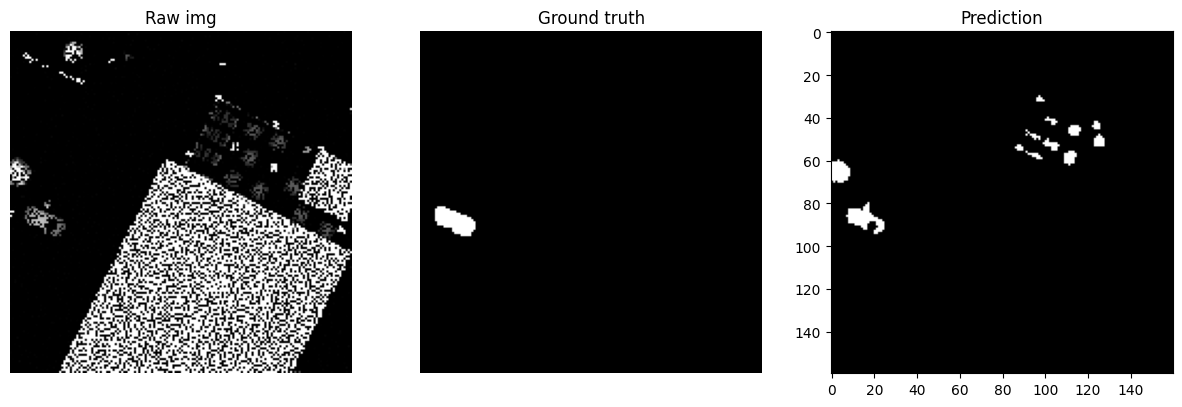

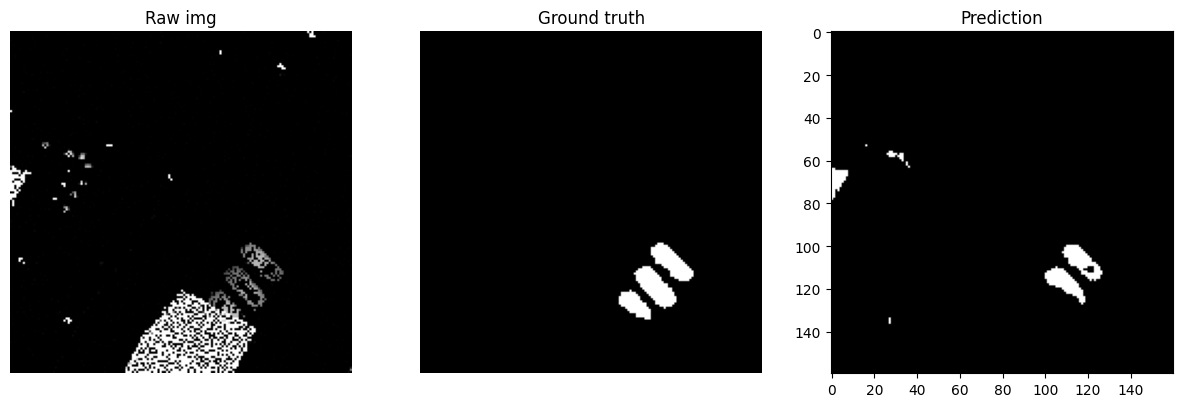

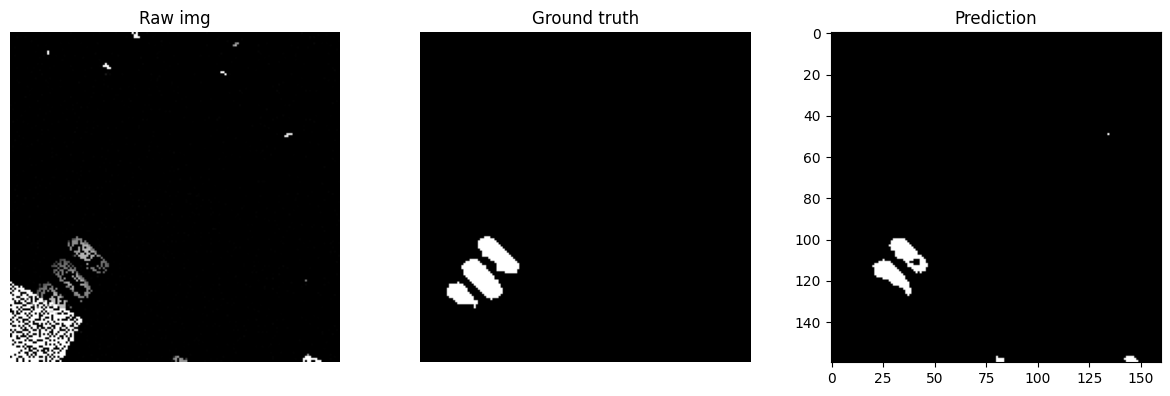

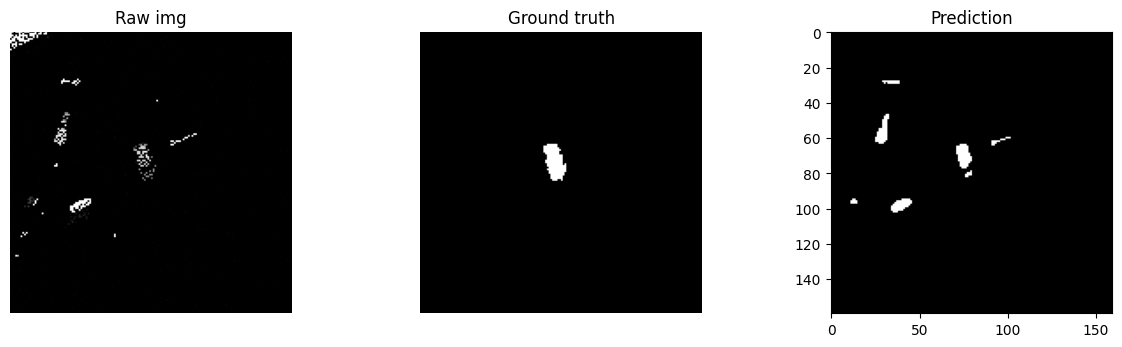

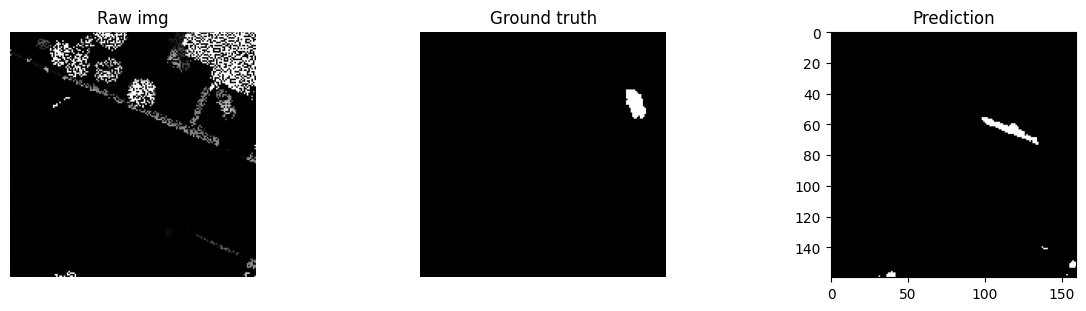

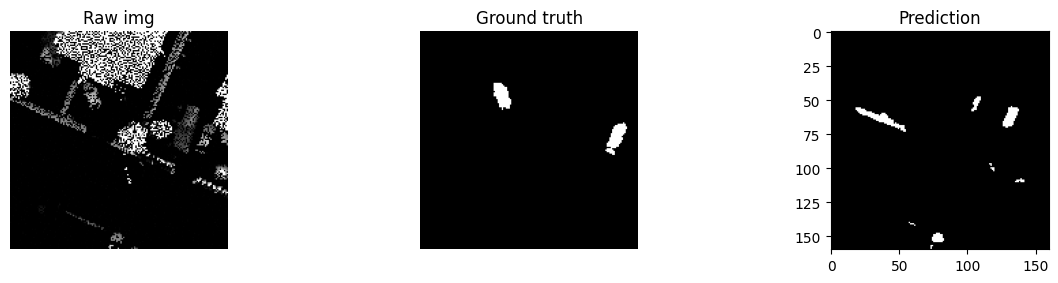

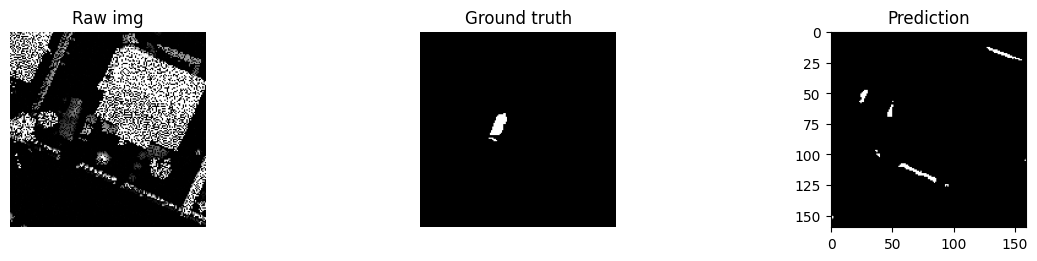

In [36]:
for idx in range(10):
    image, mask = dataset[idx]
    pred_mask, probs = predict()
    pred_np = pred_mask.squeeze().cpu().numpy()

    plt.figure(figsize=(15,30))

    plt.subplot(idx+1,3,1)
    plt.title("Raw img")
    plt.imshow(image.permute(1,2,0))
    plt.axis("off")

    plt.subplot(idx+1,3,2)
    plt.title("Ground truth")
    plt.imshow(mask.squeeze(), cmap="gray")
    plt.axis("off")

    plt.subplot(idx+1,3,3)
    plt.title("Prediction")
    plt.imshow(pred_np, cmap="gray")

    plt.show()

<a href="YOUR_REPO_URL" target="_blank" style="text-decoration: none;"> <div style=" display: inline-flex; align-items: center; gap: 10px; background: white; color: #24292f; border: 1px solid #d0d7de; border-radius: 8px; padding: 10px 14px; font-family: Arial, sans-serif; font-weight: 600; box-shadow: 0 1px 2px rgba(0,0,0,0.08); "> <img src="https://github.githubassets.com/images/modules/logos_page/GitHub-Mark.png" alt="GitHub" width="20" height="20" /> GitHub Repository - U-Net </div> </a>